
# IAT 461 / 882 Final Project
## White Sturgeon Monitoring Strategy: Initial EDA and Checkpoint Progress Report

**Name:** `Kayne Hoy`  
**SFU ID:** `301543404`  
**Date:** `August 5, 2026`

---

This notebook develops the initial stage of the final project for the Fraser River White Sturgeon Conservation Program. I use the provided White Sturgeon mark-recapture and PIT tag dataset to build a high-level overview, clean the records, and complete exploratory data analysis for the three proposed monitoring strategies.

The current milestone focuses on EDA and strategy validation. I do not build the final prediction model yet. Instead, I prepare a reliable encounter-level dataset, identify the strongest patterns, justify the direction for Phase 2, and document the assumptions and limitations that will affect the final model.


## Project Overview and Technique Selection

The client is deciding how to use a limited monitoring budget. Option A would distribute monitoring more evenly across river reaches. Option B would focus on hatchery-released fish and the places where those fish are encountered. Option C would focus on locations and conditions that are more strongly associated with large mature White Sturgeon.

I treat Phase 1 as exploratory pattern discovery rather than a supervised modeling problem. The purpose is to compare distributions, missingness, capture concentration, hatchery information, fish size, and river locations before choosing a strategy. Phase 2 is a supervised binary classification problem because the proposal defines a clear outcome: whether the fork length is at least 150 cm.

This structure follows the main course sequence. I first observe and clean the data, then engineer useful features from dates and RKM ranges, and finally prepare for classification. I use descriptive summaries and visual comparisons at this checkpoint because the main question is what the recorded data can support before I fit a model.



## Setup

I import a small set of familiar libraries for data loading, cleaning, tables, and visualization. I keep the code direct and use pandas operations so that each step can be inspected separately.


In [ ]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")



---

# 1. Data Loading and Documentation

## Data source

The dataset comes from the Province of British Columbia Data Catalogue: **White Sturgeon - Fraser River Drainage Mark-Recapture PIT Tag Data**.

Source link: https://catalogue.data.gov.bc.ca/dataset/white-sturgeon-fraser-river-drainage-mark-recapture-pit-tag-data

The attached catalogue PDF explains that the data were collected by government biologists and partner organizations, including First Nations and fisheries organizations. It also states that the data should be used with caution because records may not be verified and may change in future versions. The documented data lineage covers May 1991 to December 2020, which matches the date range that I later observe in the CSV file.



## Load the CSV file

I first load the full file without removing any rows. I rename the columns to simple snake-case names because this makes the later code easier to read. I preserve the original data values at this stage.


In [ ]:

DATA_PATH = Path("sturgeon-pit-tag-dat.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The CSV file was not found. Put sturgeon-pit-tag-dat(1).csv in the same folder as the notebook."
    )

raw_df = pd.read_csv(DATA_PATH, low_memory=False)

raw_df = raw_df.rename(columns={
    "FishID": "fish_id",
    "Tag number": "tag_number",
    "Tag type": "tag_type",
    "Year class": "year_class",
    "Confirmed hatchery-release?": "hatchery_status",
    "Capture date": "capture_date",
    "Fork length": "fork_length",
    "Girth": "girth",
    "Waterbody": "waterbody",
    "Release date": "release_date",
    "RKM_Round": "rkm_round"
})

print(f"Dataset shape: {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns")
display(raw_df.head(5))


Dataset shape: 224,134 rows and 11 columns


,fish_id,tag_number,tag_type,year_class,hatchery_status,capture_date,fork_length,girth,waterbody,release_date,rkm_round
0,1.00,88,Floy,NaN,NaN,2000-07-16,138.00,55.00,Nechako River,NaN,NaN
1,1.00,501F7A3051,PIT,NaN,NaN,2000-07-16,138.00,55.00,Nechako River,NaN,NaN
2,1.00,88,Floy,NaN,NaN,2001-10-12,147.50,58.00,Nechako River,NaN,120-130
3,1.00,501F7A3051,PIT,NaN,NaN,2001-10-12,147.50,58.00,Nechako River,NaN,120-130
4,1.00,501F7A3051,PIT,NaN,NaN,2006-05-09,165.00,68.00,Nechako River,NaN,130-140



The full file contains more than 224,000 rows, which agrees with the client proposal. One important issue is already visible in the first rows: the same fish and capture can appear more than once when the fish has more than one tag type. Therefore, I cannot assume that one CSV row always represents one separate encounter.



## Column dictionary

The source page does not provide a detailed field-by-field dictionary, so I document the fields using the column names, the proposal, and the values found in the file. I do not assign a biological meaning that is not supported by the supplied material.


In [ ]:

column_dictionary = pd.DataFrame({
    "column": [
        "fish_id", "tag_number", "tag_type", "year_class", "hatchery_status",
        "capture_date", "fork_length", "girth", "waterbody", "release_date", "rkm_round"
    ],
    "meaning": [
        "Internal identifier used to connect records for the same fish",
        "Recorded tag serial number or tag label",
        "Type of tag, such as PIT, Floy, Acoustic, or Radio",
        "Recorded hatchery year class when available",
        "Explicit confirmation that a fish is hatchery-released; blank is not treated as wild",
        "Date of a recorded fish capture",
        "Fork length measurement in centimetres; Phase 2 uses 150 cm as the threshold",
        "Girth measurement supplied in the dataset",
        "Named river or lake where the record occurred",
        "Date of a hatchery release record",
        "Rounded 10-km river segment where the record occurred"
    ]
})

display(column_dictionary)


,column,meaning
0,fish_id,Internal identifier used to connect records fo...
1,tag_number,Recorded tag serial number or tag label
2,tag_type,"Type of tag, such as PIT, Floy, Acoustic, or R..."
3,year_class,Recorded hatchery year class when available
4,hatchery_status,Explicit confirmation that a fish is hatchery-...
5,capture_date,Date of a recorded fish capture
6,fork_length,Fork length measurement in centimetres; Phase ...
7,girth,Girth measurement supplied in the dataset
8,waterbody,Named river or lake where the record occurred
9,release_date,Date of a hatchery release record



## Initial data profile

The Week 3 data cleaning material emphasizes checking data types, missingness, and unusual values before deciding how to clean a dataset. I create one profile table that shows the data type, number of missing values, missing percentage, and number of unique values for every column.


In [ ]:

profile = pd.DataFrame({
    "data_type": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_percent": (raw_df.isna().mean() * 100).round(1),
    "unique_values": raw_df.nunique(dropna=True)
}).sort_values("missing_percent", ascending=False)

display(profile)


,data_type,missing_count,missing_percent,unique_values
year_class,float64,209917,93.70,3
release_date,object,179158,79.90,59
hatchery_status,object,177219,79.10,1
girth,float64,49552,22.10,653
fork_length,float64,46945,20.90,1181
capture_date,object,44978,20.10,6446
tag_number,object,811,0.40,131080
rkm_round,object,524,0.20,91
fish_id,float64,0,0.00,130345
tag_type,object,0,0.00,4



The missingness is not evenly distributed. `year_class`, `release_date`, and `hatchery_status` are mostly blank, while `fork_length`, `girth`, and `capture_date` are missing for about one fifth of the rows. This pattern suggests that the file mixes different record types rather than containing random missing values. I investigate that structure before dropping or filling anything.



---

# 2. Data Cleaning and Encounter Construction

## Convert the date fields and separate record types

I convert both date columns to pandas datetime values. I then classify each row as a capture record, a release-only record, or a row with neither date. This step is important because release-only rows should not be counted as fish captures when I compare monitoring locations.


In [ ]:

df = raw_df.copy()

df["capture_date"] = pd.to_datetime(df["capture_date"], errors="coerce")
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df["record_type"] = "Neither date"
df.loc[df["capture_date"].notna(), "record_type"] = "Capture"
df.loc[
    df["capture_date"].isna() & df["release_date"].notna(),
    "record_type"
] = "Release only"

record_type_summary = df["record_type"].value_counts().to_frame("row_count")
record_type_summary["percent"] = (
    record_type_summary["row_count"] / len(df) * 100
).round(1)

display(record_type_summary)

print("Capture date range:", df["capture_date"].min().date(), "to", df["capture_date"].max().date())
print("Release date range:", df["release_date"].min().date(), "to", df["release_date"].max().date())


,row_count,percent
record_type,,
Capture,179156,79.90
Release only,44976,20.10
Neither date,2,0.00


Capture date range: 1991-05-17 to 2020-12-30
Release date range: 2006-10-04 to 2020-06-19



About one fifth of the rows are release-only records. Most of these are hatchery release records from the Nechako River. I keep them in the original table for documentation, but I exclude them from the capture encounter analysis. This decision prevents the release program from being incorrectly counted as monitoring encounters.

There are only two rows with neither a capture date nor a release date. I do not use them because I cannot place them in the capture timeline or the release timeline.



## Parse the river-kilometre ranges

`rkm_round` is stored as a text range such as `120-130`. For grouped EDA, the original range is already useful as a category. For the future model, I also create the start, end, and midpoint of each range. This is a simple form of feature engineering because I convert one text field into ordered numeric information.


In [ ]:

rkm_parts = df["rkm_round"].str.extract(r"(?P<rkm_start>\d+)-(?P<rkm_end>\d+)")

df["rkm_start"] = pd.to_numeric(rkm_parts["rkm_start"], errors="coerce")
df["rkm_end"] = pd.to_numeric(rkm_parts["rkm_end"], errors="coerce")
df["rkm_midpoint"] = (df["rkm_start"] + df["rkm_end"]) / 2

rkm_check = pd.DataFrame({
    "original_rkm_missing": df["rkm_round"].isna().sum(),
    "parsed_midpoint_missing": df["rkm_midpoint"].isna().sum()
}, index=["rows"])

display(rkm_check)
display(df[["rkm_round", "rkm_start", "rkm_end", "rkm_midpoint"]].drop_duplicates().head(12))


,original_rkm_missing,parsed_midpoint_missing
rows,524,524


,rkm_round,rkm_start,rkm_end,rkm_midpoint
0,NaN,NaN,NaN,NaN
2,120-130,120.00,130.00,125.00
4,130-140,130.00,140.00,135.00
6,110-120,110.00,120.00,115.00
22,90-100,90.00,100.00,95.00
59,100-110,100.00,110.00,105.00
64,60-70,60.00,70.00,65.00
137,0-10,0.00,10.00,5.00
138,950-960,950.00,960.00,955.00
148,860-870,860.00,870.00,865.00



All non-missing RKM values follow the same range format, so the midpoint conversion does not create extra missing values. I keep both forms because the category is easy to explain to the stakeholder, while the midpoint may be useful for a model that needs an ordered location feature.



## Sanity check the fork length values

A sanity check looks for values that are far outside the main distribution or conflict with the other records. I inspect the largest unique fork length values rather than immediately applying a general outlier rule. I do this because very large fish are the target of the project, so a standard IQR filter could incorrectly remove valid large fish.


In [ ]:

largest_unique_lengths = (
    df["fork_length"]
    .dropna()
    .drop_duplicates()
    .sort_values(ascending=False)
    .head(25)
    .reset_index(drop=True)
    .to_frame("fork_length")
)

display(largest_unique_lengths)


,fork_length
0,"1,106.00"
1,"1,105.00"
2,"1,096.00"
3,"1,088.00"
4,"1,087.00"
5,"1,086.00"
6,"1,085.00"
7,"1,084.00"
8,"1,083.00"
9,"1,081.00"



The values from 1,074 to 1,106 are separated from the next largest value of 345 by a very large gap. Several of these rows occur on the same dates and locations as more realistic measurements for the same fish. This pattern looks like a data-entry problem rather than a valid extension of the distribution.

I set fork lengths above 400 to missing instead of deleting the full rows or guessing a corrected value. Only 23 raw rows meet this rule. I preserve valid large fish up to 345 cm and avoid inventing replacements for the questionable values.


In [ ]:

df["fork_length_clean"] = df["fork_length"].where(df["fork_length"] <= 400)

fork_cleaning_summary = pd.DataFrame({
    "check": ["Raw non-missing fork lengths", "Values above 400 set to missing", "Clean non-missing fork lengths"],
    "row_count": [
        df["fork_length"].notna().sum(),
        (df["fork_length"] > 400).sum(),
        df["fork_length_clean"].notna().sum()
    ]
})

display(fork_cleaning_summary)


,check,row_count
0,Raw non-missing fork lengths,177189
1,Values above 400 set to missing,23
2,Clean non-missing fork lengths,177166



## Build one encounter-level table

The dataset can repeat one capture because a fish may have multiple tag types or multiple tag rows. The proposal also warns that the same fish can be captured on different dates. I need to handle these two situations differently.

I define one encounter as one fish on one capture date in one waterbody and one RKM segment. I combine repeated tag rows inside that encounter. If the repeated rows contain more than one distinct plausible fork length, I mark the fork length as missing because I cannot determine which measurement is correct. This keeps one encounter for the frequency analysis without forcing an uncertain size value into the Option C analysis.


In [ ]:

capture_rows = df[df["capture_date"].notna()].copy()

capture_rows["fork_round"] = capture_rows["fork_length_clean"].round(1)
capture_rows["girth_round"] = capture_rows["girth"].round(1)
capture_rows["hatchery_confirmed"] = capture_rows["hatchery_status"].eq("Hatchery")

encounter_keys = ["fish_id", "capture_date", "waterbody", "rkm_round"]

encounters = (
    capture_rows.groupby(encounter_keys, dropna=False, as_index=False)
    .agg(
        fork_length=("fork_length_clean", "median"),
        fork_value_count=("fork_round", "nunique"),
        girth=("girth", "median"),
        girth_value_count=("girth_round", "nunique"),
        hatchery_confirmed=("hatchery_confirmed", "max"),
        year_class=("year_class", "first"),
        tag_rows=("tag_type", "size"),
        first_tag_type=("tag_type", "first")
    )
)

encounters["fork_conflict"] = encounters["fork_value_count"] > 1
encounters.loc[encounters["fork_conflict"], "fork_length"] = np.nan

encounters["capture_year"] = encounters["capture_date"].dt.year
encounters["capture_month"] = encounters["capture_date"].dt.month

rkm_parts_encounter = encounters["rkm_round"].str.extract(r"(?P<rkm_start>\d+)-(?P<rkm_end>\d+)")
encounters["rkm_start"] = pd.to_numeric(rkm_parts_encounter["rkm_start"], errors="coerce")
encounters["rkm_end"] = pd.to_numeric(rkm_parts_encounter["rkm_end"], errors="coerce")
encounters["rkm_midpoint"] = (encounters["rkm_start"] + encounters["rkm_end"]) / 2

cleaning_summary = pd.DataFrame({
    "stage": [
        "All CSV rows",
        "Rows with a capture date",
        "Encounter-level rows after combining repeated tag rows",
        "Encounter rows with usable fork length"
    ],
    "row_count": [
        len(df),
        len(capture_rows),
        len(encounters),
        encounters["fork_length"].notna().sum()
    ]
})

display(cleaning_summary)

print(f"Repeated tag rows combined: {len(capture_rows) - len(encounters):,}")
print(f"Encounters with conflicting fork length values: {encounters['fork_conflict'].sum():,}")


,stage,row_count
0,All CSV rows,224134
1,Rows with a capture date,179156
2,Encounter-level rows after combining repeated ...,176867
3,Encounter rows with usable fork length,174759


Repeated tag rows combined: 2,289
Encounters with conflicting fork length values: 152



The encounter table contains about 176,000 observations. Combining tag rows removes more than 2,000 repeated rows, while only a small number of encounters have conflicting plausible fork length measurements. I keep all encounters for location-frequency analysis, but I use only the size-complete encounters when I calculate the large mature class.

I do not fill missing fork length with an average or median because fork length defines the target. Imputing it would create artificial labels and could bias both the strategy comparison and the future classifier.



---

# 3. High-Level Dataset Overview

## Encounter counts, unique fish, and recaptures

One fish may appear in several encounters over time. I calculate the number of encounters per fish so I can understand how much repeated-measures structure exists in the data. This matters for Phase 2 because the same fish should not appear in both the training and test sets.


In [ ]:

encounters_per_fish = encounters.groupby("fish_id").size()

high_level_overview = pd.DataFrame({
    "measure": [
        "Encounter rows",
        "Unique captured fish",
        "Fish with two or more encounters",
        "Share of fish with two or more encounters",
        "Median encounters per fish",
        "Maximum encounters for one fish"
    ],
    "value": [
        f"{len(encounters):,}",
        f"{encounters['fish_id'].nunique():,}",
        f"{(encounters_per_fish >= 2).sum():,}",
        f"{(encounters_per_fish >= 2).mean() * 100:.1f}%",
        f"{encounters_per_fish.median():.0f}",
        f"{encounters_per_fish.max():.0f}"
    ]
})

display(high_level_overview)
display(encounters_per_fish.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("encounters_per_fish"))


,measure,value
0,Encounter rows,"176,867"
1,Unique captured fish,"87,270"
2,Fish with two or more encounters,"38,922"
3,Share of fish with two or more encounters,44.6%
4,Median encounters per fish,1
5,Maximum encounters for one fish,70


,encounters_per_fish
count,"87,270.00"
mean,2.03
std,1.78
min,1.00
50%,1.00
75%,2.00
90%,4.00
95%,5.00
99%,9.00
max,70.00



Almost half of the captured fish have at least two recorded encounters. This confirms that the rows are not independent observations from completely different fish. For the final model, I will split the data by `fish_id` rather than using a simple random row split. This will test whether the model generalizes to fish that it has not already seen.



## Fork length distribution and the project threshold

The client defines a large mature size class as fork length greater than or equal to 150 cm. I visualize the cleaned length distribution and mark this threshold. A histogram is appropriate because I want to see the shape, spread, and balance of one continuous variable.


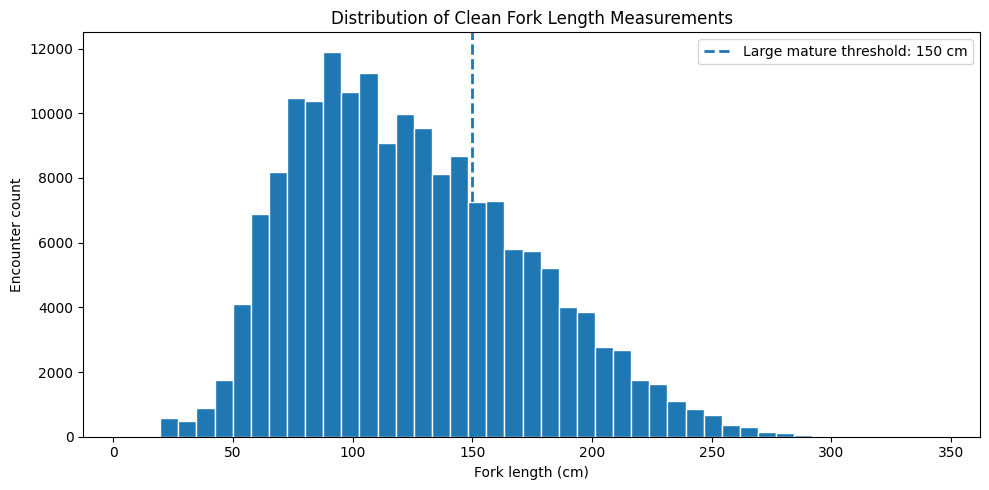

,class,encounters,percent
0,Below 150 cm,123928,70.90
1,At least 150 cm,50831,29.10


In [ ]:

size_complete = encounters[encounters["fork_length"].notna()].copy()
size_complete["large_mature"] = size_complete["fork_length"] >= 150

plt.figure(figsize=(10, 5))
plt.hist(size_complete["fork_length"], bins=45, edgecolor="white")
plt.axvline(150, linestyle="--", linewidth=2, label="Large mature threshold: 150 cm")
plt.xlabel("Fork length (cm)")
plt.ylabel("Encounter count")
plt.title("Distribution of Clean Fork Length Measurements")
plt.legend()
plt.tight_layout()
plt.show()

large_summary = pd.DataFrame({
    "class": ["Below 150 cm", "At least 150 cm"],
    "encounters": [
        (~size_complete["large_mature"]).sum(),
        size_complete["large_mature"].sum()
    ]
})
large_summary["percent"] = (
    large_summary["encounters"] / large_summary["encounters"].sum() * 100
).round(1)

display(large_summary)



The target class is not extremely rare. About 29% of the size-complete encounters meet the 150 cm threshold. This is enough to support classification, but it is still imbalanced because the smaller class is much larger. For this reason, I will not evaluate the final model with accuracy alone. Precision, recall, F1, and ROC-AUC will give a more complete view of performance.



## Capture records over time

I extract the capture year from the date, which follows the Week 5 approach of creating useful features from timestamps. I plot encounter counts by year to check whether the amount of data is stable across the study period.


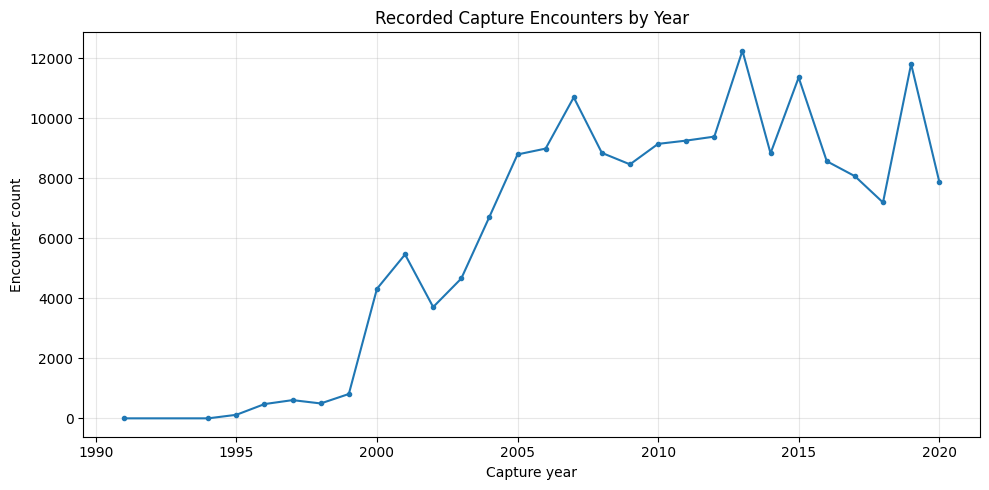

,capture_year,encounter_count,unique_fish
18,2011,9252,8467
19,2012,9385,8622
20,2013,12246,10959
21,2014,8828,7934
22,2015,11355,10057
23,2016,8565,7645
24,2017,8067,7281
25,2018,7191,6534
26,2019,11803,10468
27,2020,7889,7274


In [ ]:

yearly_summary = (
    encounters.groupby("capture_year")
    .agg(
        encounter_count=("fish_id", "size"),
        unique_fish=("fish_id", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(yearly_summary["capture_year"], yearly_summary["encounter_count"], marker="o", markersize=3)
plt.xlabel("Capture year")
plt.ylabel("Encounter count")
plt.title("Recorded Capture Encounters by Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(yearly_summary.tail(10))



The amount of recorded data changes substantially across years. The earliest years contain very few records, while later years contain thousands. This means that a location pattern may partly reflect changes in survey programs, tagging practices, or reporting over time. I will include time features in the model and examine a time-aware validation check in addition to the fish-level split.



---

# 4. Summary Tables for the Three Strategy Options

I create waterbody and waterbody-RKM summaries once so that the three options are compared from the same encounter-level dataset. I calculate the number of encounters, number of unique fish, number of size-complete encounters, median fork length, number of confirmed hatchery encounters, number of large mature encounters, and the observed large mature share.

The large mature share is a descriptive share of the recorded size-complete encounters. It is not a population estimate and it is not adjusted for survey effort.


In [ ]:

encounters["large_mature"] = (encounters["fork_length"] >= 150).astype("Int64")
encounters.loc[encounters["fork_length"].isna(), "large_mature"] = pd.NA

waterbody_summary = (
    encounters.groupby("waterbody")
    .agg(
        encounters=("fish_id", "size"),
        unique_fish=("fish_id", "nunique"),
        fork_complete=("large_mature", "count"),
        median_fork_length=("fork_length", "median"),
        large_count=("large_mature", "sum"),
        confirmed_hatchery_count=("hatchery_confirmed", "sum"),
        missing_rkm=("rkm_round", lambda values: values.isna().sum())
    )
)

waterbody_summary["encounter_share_percent"] = (
    waterbody_summary["encounters"] / waterbody_summary["encounters"].sum() * 100
)
waterbody_summary["fork_complete_percent"] = (
    waterbody_summary["fork_complete"] / waterbody_summary["encounters"] * 100
)
waterbody_summary["large_share_percent"] = (
    waterbody_summary["large_count"] / waterbody_summary["fork_complete"] * 100
)

segment_summary = (
    encounters.groupby(["waterbody", "rkm_round"], dropna=False)
    .agg(
        encounters=("fish_id", "size"),
        unique_fish=("fish_id", "nunique"),
        fork_complete=("large_mature", "count"),
        median_fork_length=("fork_length", "median"),
        large_count=("large_mature", "sum"),
        confirmed_hatchery_count=("hatchery_confirmed", "sum")
    )
)

segment_summary["fork_complete_percent"] = (
    segment_summary["fork_complete"] / segment_summary["encounters"] * 100
)
segment_summary["large_share_percent"] = (
    segment_summary["large_count"] / segment_summary["fork_complete"] * 100
)

waterbody_display = waterbody_summary.sort_values("encounters", ascending=False).round(1)
display(waterbody_display)


,encounters,unique_fish,fork_complete,median_fork_length,large_count,confirmed_hatchery_count,missing_rkm,encounter_share_percent,fork_complete_percent,large_share_percent
waterbody,,,,,,,,,,
Fraser River,158571,81411,157731,115.00,42790,102,227,89.70,99.50,27.10
Harrison River,12792,6110,12725,155.00,7160,0,0,7.20,99.50,56.30
Nechako River,2749,2235,1556,75.10,522,1809,13,1.60,56.60,33.50
Pitt River,2644,2310,2636,100.00,307,2,0,1.50,99.70,11.60
Bowron River,40,39,40,90.50,5,1,0,0.00,100.00,12.50
Stuart Lake,27,25,27,198.00,26,0,27,0.00,100.00,96.30
Fraser Lake,19,19,19,72.20,4,13,19,0.00,100.00,21.10
Harrison Lake,14,14,14,170.50,10,0,0,0.00,100.00,71.40
Stuart River,6,6,6,156.50,4,0,2,0.00,100.00,66.70



---

# 5. Option A: Distribute Monitoring More Evenly

## Where are the recorded encounters concentrated?

I first compare encounter counts across waterbodies. A bar chart makes the size difference easy to see. I use encounter-level records rather than raw rows so that fish with multiple tags are not counted more than once during the same encounter.


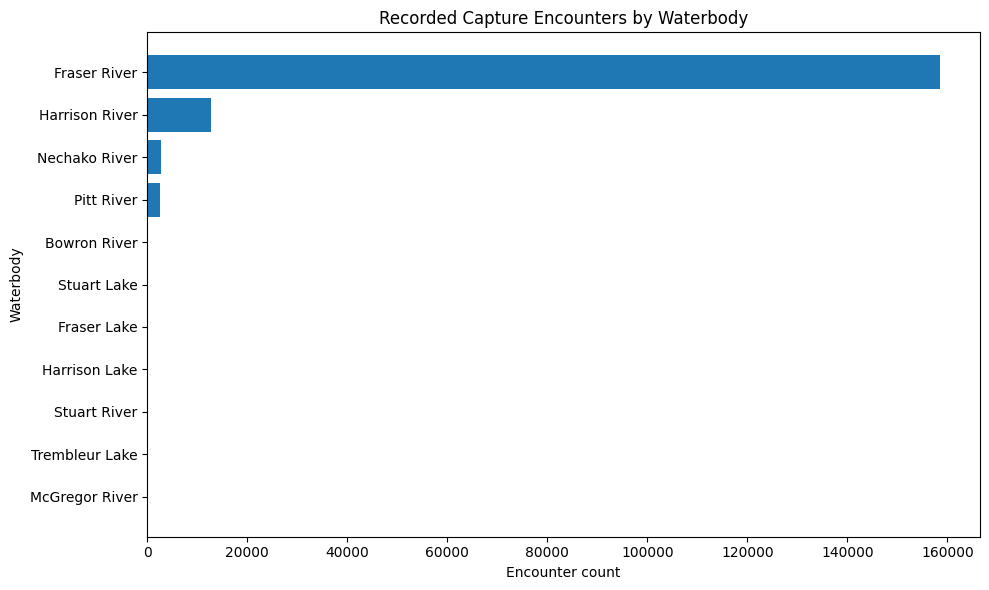

,encounters,unique_fish,encounter_share_percent
waterbody,,,
Fraser River,158571,81411,89.66
Harrison River,12792,6110,7.23
Nechako River,2749,2235,1.55
Pitt River,2644,2310,1.49
Bowron River,40,39,0.02
Stuart Lake,27,25,0.02
Fraser Lake,19,19,0.01
Harrison Lake,14,14,0.01
Stuart River,6,6,0.00


In [ ]:

waterbody_counts = waterbody_summary.sort_values("encounters", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(waterbody_counts.index, waterbody_counts["encounters"])
plt.xlabel("Encounter count")
plt.ylabel("Waterbody")
plt.title("Recorded Capture Encounters by Waterbody")
plt.tight_layout()
plt.show()

option_a_waterbody = waterbody_summary[
    ["encounters", "unique_fish", "encounter_share_percent"]
].sort_values("encounters", ascending=False).round(2)

display(option_a_waterbody)



The encounter records are highly concentrated in the Fraser River. Approximately 89.7% of the encounter-level records come from that waterbody, followed by the Harrison River at about 7.2%. Several lakes and smaller rivers have fewer than 50 encounters.

This confirms that the database is not evenly distributed across waterbodies. However, it does not show why the distribution is uneven. The dataset does not contain survey hours, number of nets, number of crews, unsuccessful surveys, or total monitoring cost. Therefore, I cannot separate monitoring effort from fish availability or reporting practices.



## Concentration within waterbody-RKM segments

I also inspect the individual waterbody-RKM combinations with the largest number of encounters. I keep the waterbody name attached to the RKM range because the same range label can exist in different rivers.


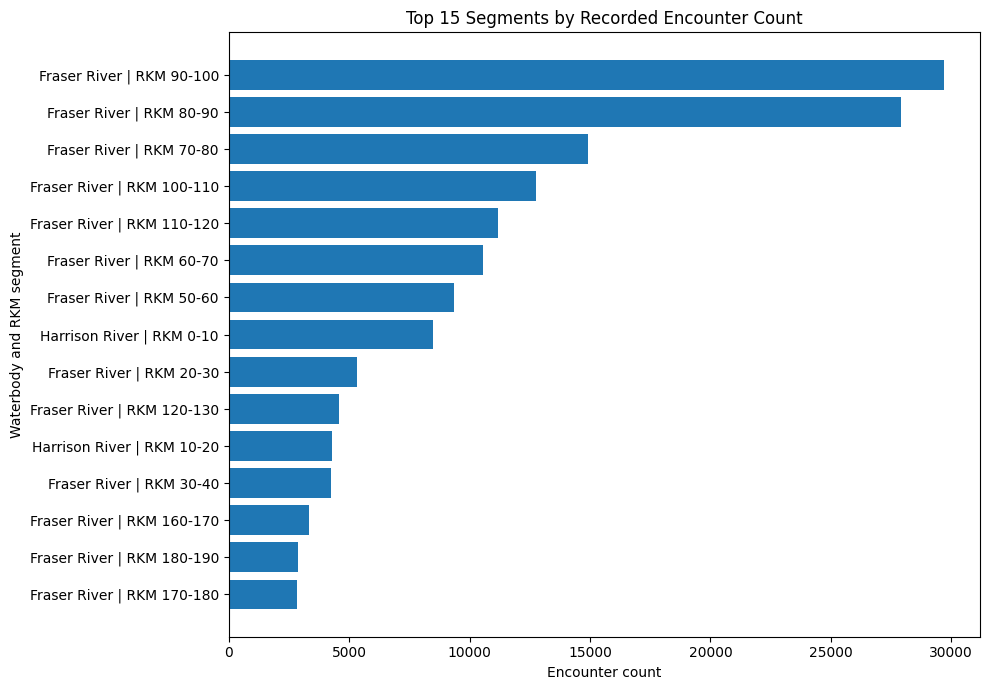

,waterbody,rkm_round,encounters,unique_fish,fork_complete
0,Fraser River,90-100,29708,20296,29574
1,Fraser River,80-90,27896,21439,27778
2,Fraser River,70-80,14918,12243,14874
3,Fraser River,100-110,12746,8773,12685
4,Fraser River,110-120,11188,7747,11152
5,Fraser River,60-70,10562,8693,10536
6,Fraser River,50-60,9345,7637,9111
7,Harrison River,0-10,8493,4613,8440
8,Fraser River,20-30,5309,4548,5295
9,Fraser River,120-130,4594,3480,4579


In [ ]:

top_segments_by_encounters = (
    segment_summary.reset_index()
    .dropna(subset=["rkm_round"])
    .sort_values("encounters", ascending=False)
    .head(15)
    .copy()
)

top_segments_by_encounters["segment"] = (
    top_segments_by_encounters["waterbody"] + " | RKM " + top_segments_by_encounters["rkm_round"]
)

plot_a_segments = top_segments_by_encounters.sort_values("encounters", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_a_segments["segment"], plot_a_segments["encounters"])
plt.xlabel("Encounter count")
plt.ylabel("Waterbody and RKM segment")
plt.title("Top 15 Segments by Recorded Encounter Count")
plt.tight_layout()
plt.show()

display(
    top_segments_by_encounters[
        ["waterbody", "rkm_round", "encounters", "unique_fish", "fork_complete"]
    ].reset_index(drop=True)
)



The two largest segments are Fraser River RKM 90-100 and RKM 80-90. Together, they account for almost one third of all encounter-level records. This is strong evidence of concentration in the database, but it is not enough to conclude that monitoring should be redistributed evenly.

My current assessment is that Option A is only partially supported. The data can identify underrepresented and overrepresented segments, but it cannot evaluate the efficiency of current effort because the required effort denominator is missing. An even distribution could also reduce monitoring in locations where important fish are more frequently encountered.



---

# 6. Option B: Prioritize Confirmed Hatchery-Released Fish

## Coverage of the hatchery field

The hatchery column contains the value `Hatchery` or a blank. I treat the blank as unknown or not explicitly confirmed. I do not rename it as wild because the supplied data does not support that interpretation.

I compare release-only rows with captured encounters so that the large number of release records does not get mixed with recapture evidence.


,record_group,count
0,Release-only rows marked Hatchery,44976
1,Capture encounters explicitly confirmed as Hat...,1927
2,All capture encounters,176867


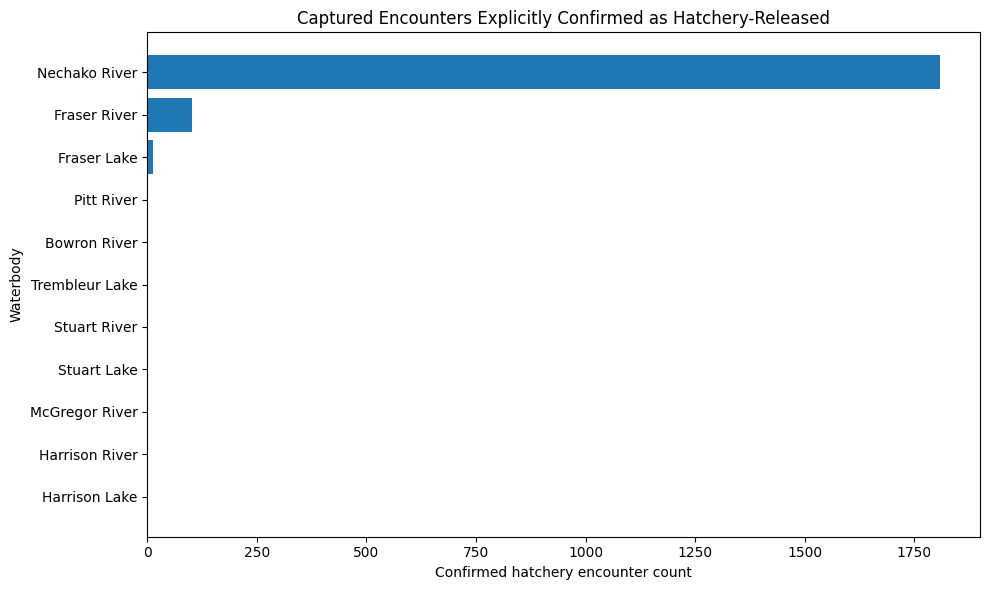

,encounters,confirmed_hatchery_count
waterbody,,
Nechako River,2749,1809
Fraser River,158571,102
Fraser Lake,19,13
Pitt River,2644,2
Bowron River,40,1
Harrison River,12792,0
Harrison Lake,14,0
McGregor River,2,0
Stuart Lake,27,0


In [ ]:

hatchery_context = pd.DataFrame({
    "record_group": [
        "Release-only rows marked Hatchery",
        "Capture encounters explicitly confirmed as Hatchery",
        "All capture encounters"
    ],
    "count": [
        df.loc[df["record_type"].eq("Release only") & df["hatchery_status"].eq("Hatchery")].shape[0],
        encounters["hatchery_confirmed"].sum(),
        len(encounters)
    ]
})

display(hatchery_context)

hatchery_by_waterbody = (
    waterbody_summary[["encounters", "confirmed_hatchery_count"]]
    .sort_values("confirmed_hatchery_count", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(hatchery_by_waterbody.index, hatchery_by_waterbody["confirmed_hatchery_count"])
plt.xlabel("Confirmed hatchery encounter count")
plt.ylabel("Waterbody")
plt.title("Captured Encounters Explicitly Confirmed as Hatchery-Released")
plt.tight_layout()
plt.show()

display(
    waterbody_summary[
        ["encounters", "confirmed_hatchery_count"]
    ].sort_values("confirmed_hatchery_count", ascending=False)
)



There are 1,927 encounter-level capture records explicitly confirmed as hatchery-released. About 94% of these confirmed hatchery encounters occur in the Nechako River. The Fraser River has only a small number of explicitly confirmed hatchery encounters compared with its very large total number of encounters.

This result identifies the Nechako River as the main area represented by the hatchery field. However, the field is one-sided and mostly blank. I can find confirmed hatchery fish, but I cannot reliably compare them with a clearly labelled wild group across the full drainage.



## RKM segments with confirmed hatchery encounters

I list the segments with the largest number of confirmed hatchery encounters. This shows whether the available hatchery information is concentrated within the Nechako River as well as across waterbodies.


In [ ]:

top_hatchery_segments = (
    segment_summary.reset_index()
    .query("confirmed_hatchery_count > 0")
    .sort_values("confirmed_hatchery_count", ascending=False)
    .head(15)
)

display(
    top_hatchery_segments[
        [
            "waterbody", "rkm_round", "encounters",
            "confirmed_hatchery_count", "fork_complete", "large_count"
        ]
    ].reset_index(drop=True)
)


,waterbody,rkm_round,encounters,confirmed_hatchery_count,fork_complete,large_count
0,Nechako River,110-120,1155,618,935,297
1,Nechako River,120-130,735,545,283,103
2,Nechako River,130-140,442,340,157,77
3,Nechako River,100-110,211,192,51,7
4,Nechako River,190-200,57,55,11,0
5,Fraser River,760-770,21,15,21,2
6,Fraser River,680-690,21,14,21,0
7,Fraser River,550-560,280,13,276,121
8,Fraser Lake,NaN,19,13,19,4
9,Nechako River,160-170,13,13,0,0



The largest confirmed hatchery concentrations are Nechako River RKM 110-120, 120-130, and 130-140. This makes Option B understandable as a specialized hatchery-monitoring strategy, but the evidence is narrow. It would direct the program toward one main river and a small subset of confirmed fish.

My current assessment is that Option B is not the strongest general monitoring strategy for this dataset. It may be useful for a specific hatchery-program objective, but the missing and one-sided status field limits a drainage-wide comparison.



---

# 7. Option C: Prioritize Encounters with Large Mature Fish

## Large mature share by waterbody

Option C can be tested more directly because the proposal provides an explicit size threshold and the dataset contains a large number of fork length measurements. I first compare waterbodies with at least 100 size-complete encounters. This minimum prevents very small waterbodies with only a few records from appearing more reliable than they are.


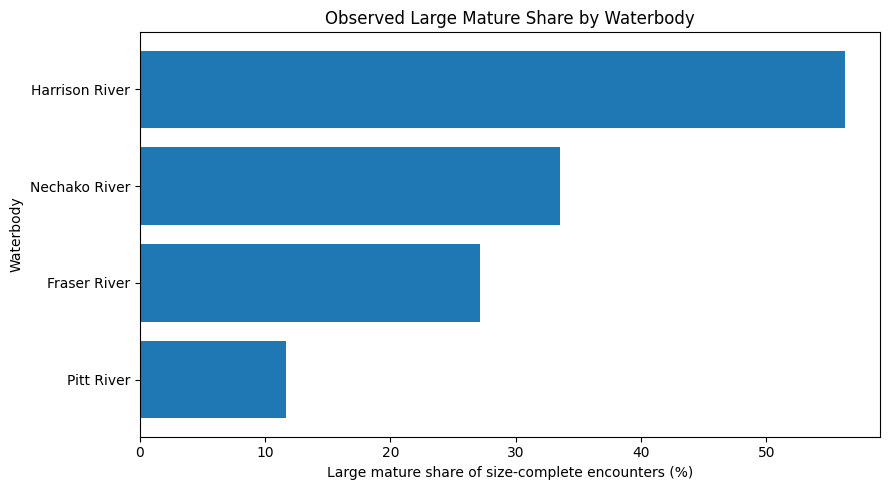

,encounters,fork_complete,median_fork_length,large_count,large_share_percent,fork_complete_percent
waterbody,,,,,,
Harrison River,12792,12725,155.00,7160,56.30,99.50
Nechako River,2749,1556,75.10,522,33.50,56.60
Fraser River,158571,157731,115.00,42790,27.10,99.50
Pitt River,2644,2636,100.00,307,11.60,99.70


In [ ]:

reliable_waterbodies = (
    waterbody_summary[waterbody_summary["fork_complete"] >= 100]
    .sort_values("large_share_percent", ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(reliable_waterbodies.index, reliable_waterbodies["large_share_percent"])
plt.xlabel("Large mature share of size-complete encounters (%)")
plt.ylabel("Waterbody")
plt.title("Observed Large Mature Share by Waterbody")
plt.tight_layout()
plt.show()

display(
    reliable_waterbodies[
        [
            "encounters", "fork_complete", "median_fork_length",
            "large_count", "large_share_percent", "fork_complete_percent"
        ]
    ].sort_values("large_share_percent", ascending=False).round(1)
)



Among the well-represented waterbodies, the Harrison River has the highest observed large mature share at about 56%. The Fraser River has a lower share of about 27%, but it contributes the largest absolute number of large mature encounters because it has much more data. The Nechako River requires extra caution because only about 57% of its encounter records have a usable fork length.

This comparison already supports Option C more directly than the other strategies. The size outcome is well defined, and the recorded share changes substantially by waterbody.



## High-rate waterbody-RKM segments

For a more detailed comparison, I keep segments with at least 100 size-complete encounters and at least 80% fork length completeness. These rules reduce the risk that a segment appears strong because of a tiny or highly incomplete sample.


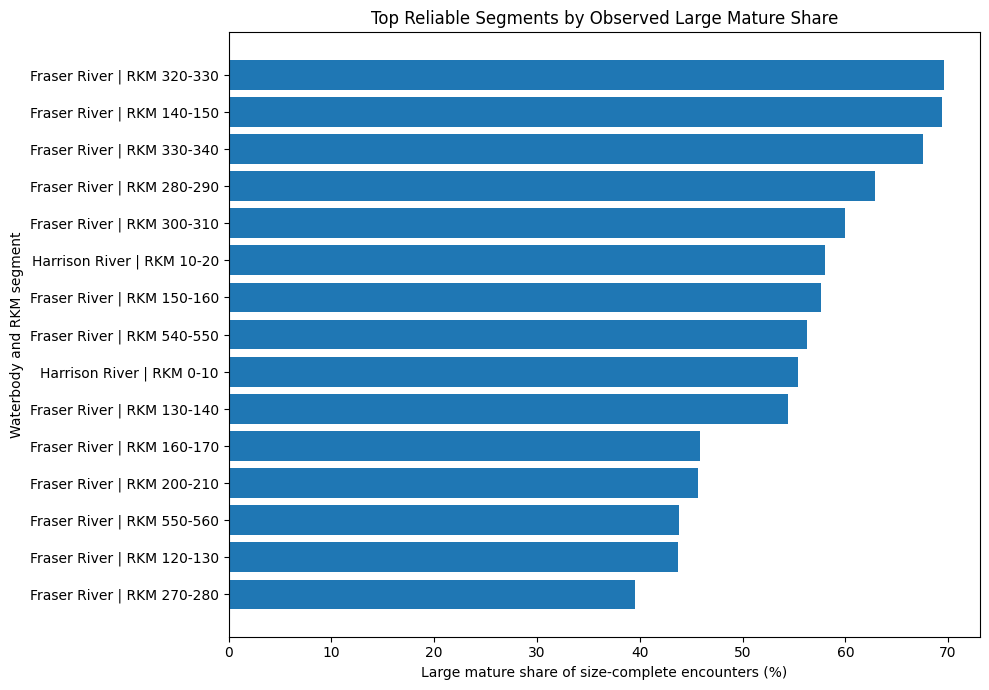

,waterbody,rkm_round,encounters,fork_complete,large_count,large_share_percent,median_fork_length,fork_complete_percent
0,Fraser River,320-330,1483,1478,1029,69.60,180.00,99.70
1,Fraser River,140-150,2584,2582,1792,69.40,179.00,99.90
2,Fraser River,330-340,2640,2626,1773,67.50,174.00,99.50
3,Fraser River,280-290,161,159,100,62.90,167.00,98.80
4,Fraser River,300-310,281,280,168,60.00,172.50,99.60
5,Harrison River,10-20,4299,4285,2485,58.00,157.00,99.70
6,Fraser River,150-160,1772,1766,1018,57.60,161.00,99.70
7,Fraser River,540-550,243,238,134,56.30,163.50,97.90
8,Harrison River,0-10,8493,8440,4675,55.40,154.00,99.40
9,Fraser River,130-140,2586,2573,1400,54.40,156.00,99.50


In [ ]:

reliable_segments = (
    segment_summary.reset_index()
    .dropna(subset=["rkm_round"])
    .query("fork_complete >= 100 and fork_complete_percent >= 80")
    .sort_values(["large_share_percent", "large_count"], ascending=False)
    .copy()
)

reliable_segments["segment"] = (
    reliable_segments["waterbody"] + " | RKM " + reliable_segments["rkm_round"]
)

top_rate_segments = reliable_segments.head(15).copy()
plot_c_rate = top_rate_segments.sort_values("large_share_percent", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_c_rate["segment"], plot_c_rate["large_share_percent"])
plt.xlabel("Large mature share of size-complete encounters (%)")
plt.ylabel("Waterbody and RKM segment")
plt.title("Top Reliable Segments by Observed Large Mature Share")
plt.tight_layout()
plt.show()

display(
    top_rate_segments[
        [
            "waterbody", "rkm_round", "encounters", "fork_complete",
            "large_count", "large_share_percent", "median_fork_length",
            "fork_complete_percent"
        ]
    ].reset_index(drop=True).round(1)
)



Several Fraser River segments have both a large sample and a high observed share. RKM 320-330, 140-150, and 330-340 each have large mature shares close to 68% to 70%. Harrison River RKM 0-10 and 10-20 also show high shares and thousands of large mature encounters.

These segments are more convincing than tiny segments with one or two fish because the pattern is supported by hundreds or thousands of size-complete encounters. They provide a clear starting point for the Phase 2 classifier and for a stakeholder discussion about targeted monitoring.



## Segments with the largest absolute number of large mature encounters

A high share and a high count answer different questions. The share is closer to monitoring efficiency, while the count shows where the current dataset has repeatedly documented large fish. I compare the largest counts so that I do not select a segment only because its denominator is smaller.


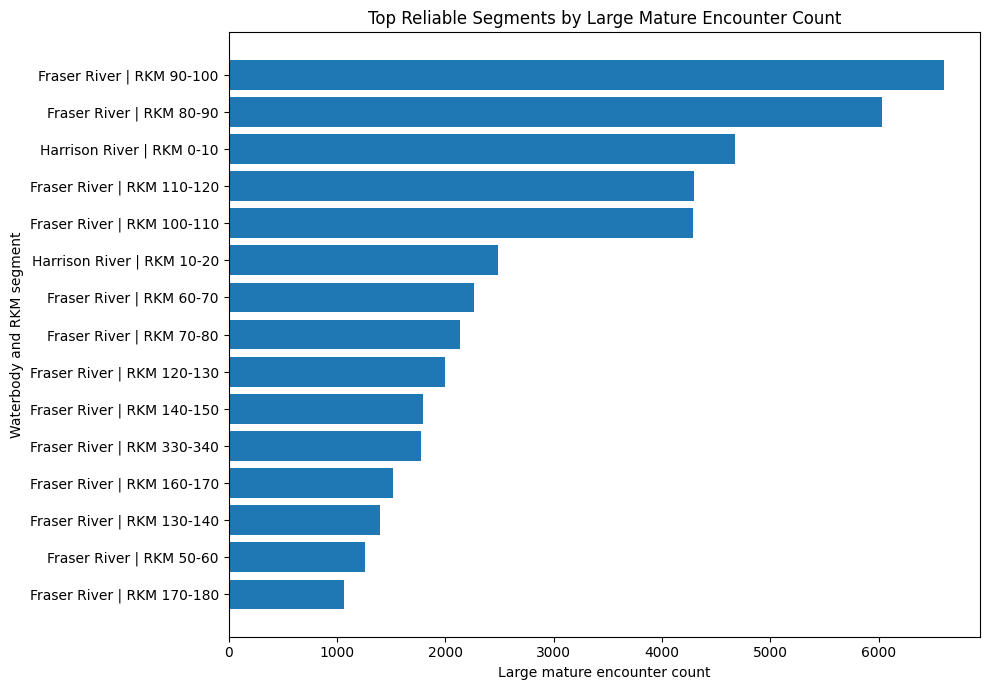

,waterbody,rkm_round,fork_complete,large_count,large_share_percent
0,Fraser River,90-100,29574,6605,22.30
1,Fraser River,80-90,27778,6032,21.70
2,Harrison River,0-10,8440,4675,55.40
3,Fraser River,110-120,11152,4296,38.50
4,Fraser River,100-110,12685,4286,33.80
5,Harrison River,10-20,4285,2485,58.00
6,Fraser River,60-70,10536,2269,21.50
7,Fraser River,70-80,14874,2135,14.40
8,Fraser River,120-130,4579,2000,43.70
9,Fraser River,140-150,2582,1792,69.40


In [ ]:

top_count_segments = (
    reliable_segments
    .sort_values(["large_count", "large_share_percent"], ascending=False)
    .head(15)
    .copy()
)

plot_c_count = top_count_segments.sort_values("large_count", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_c_count["segment"], plot_c_count["large_count"])
plt.xlabel("Large mature encounter count")
plt.ylabel("Waterbody and RKM segment")
plt.title("Top Reliable Segments by Large Mature Encounter Count")
plt.tight_layout()
plt.show()

display(
    top_count_segments[
        [
            "waterbody", "rkm_round", "fork_complete",
            "large_count", "large_share_percent"
        ]
    ].reset_index(drop=True).round(1)
)



Fraser River RKM 90-100 and 80-90 have the largest absolute number of large mature encounter records, although their large mature shares are lower than the highest-rate segments. Harrison River RKM 0-10 combines a high count with a high share. This difference shows why the final decision should not rely on a single ranking.

For Option C, I would prioritize segments that have a strong observed share, substantial sample size, and useful absolute counts. The final model can then estimate how much location, time, and hatchery information contribute after these variables are considered together.



---

# 8. Preliminary Strategy Decision

I summarize the current evidence in one table. The support level is based on what the supplied dataset can answer, not on whether a strategy might be useful with additional data.


In [ ]:

strategy_comparison = pd.DataFrame({
    "option": [
        "Option A: More even monitoring",
        "Option B: Hatchery-focused monitoring",
        "Option C: Large mature fish locations"
    ],
    "what_the_data_supports": [
        "The records are highly concentrated by waterbody and RKM segment.",
        "Confirmed hatchery encounters are strongly concentrated in the Nechako River.",
        "Fork length is available for a large majority of capture encounters, and large mature shares differ clearly by location."
    ],
    "main_limitation": [
        "No survey-effort denominator, cost, or unsuccessful survey information.",
        "Blank status is not an explicit wild label, and the confirmed records are narrow in coverage.",
        "Observed records still reflect historical effort and cannot estimate population abundance."
    ],
    "checkpoint_assessment": [
        "Partial support only",
        "Useful for a narrow hatchery objective",
        "Strongest support for the stated project"
    ]
})

display(strategy_comparison)


,option,what_the_data_supports,main_limitation,checkpoint_assessment
0,Option A: More even monitoring,The records are highly concentrated by waterbo...,"No survey-effort denominator, cost, or unsucce...",Partial support only
1,Option B: Hatchery-focused monitoring,Confirmed hatchery encounters are strongly con...,"Blank status is not an explicit wild label, an...",Useful for a narrow hatchery objective
2,Option C: Large mature fish locations,Fork length is available for a large majority ...,Observed records still reflect historical effo...,Strongest support for the stated project



Based on the current EDA, I recommend continuing with **Option C**. It is the only option that connects a clearly defined outcome to a field with broad usable coverage. The data identifies meaningful differences across waterbodies and RKM segments, and these differences can be developed into a supervised classification problem.

This recommendation does not mean that the highest recorded segment is automatically the best place to spend money. The records are affected by past monitoring effort. Instead, the EDA shows that Option C is the option that the current data can test most directly and responsibly.



---

# 9. Phase 2 Modeling Plan

## Proposed modeling dataset and target

I prepare the expected model sample without fitting a model. I require a usable fork length, waterbody, and RKM segment because these are necessary for the target and the main location features. I keep the same encounter-level unit so that multiple tag rows do not become repeated training examples.


In [ ]:

model_data = encounters.dropna(
    subset=["fork_length", "waterbody", "rkm_round", "rkm_midpoint"]
).copy()

model_data["large_mature"] = (model_data["fork_length"] >= 150).astype(int)

model_readiness = pd.DataFrame({
    "measure": [
        "Encounter rows ready for location-based modeling",
        "Unique fish in modeling data",
        "Large mature encounters",
        "Large mature class percentage"
    ],
    "value": [
        f"{len(model_data):,}",
        f"{model_data['fish_id'].nunique():,}",
        f"{model_data['large_mature'].sum():,}",
        f"{model_data['large_mature'].mean() * 100:.1f}%"
    ]
})

display(model_readiness)


,measure,value
0,Encounter rows ready for location-based modeling,"174,471"
1,Unique fish in modeling data,"85,895"
2,Large mature encounters,"50,728"
3,Large mature class percentage,29.1%



## Feature choices and leakage control

I will use location and time information that could help the program decide where and when to monitor. I will not use identifiers as predictors. I will also exclude girth from the main model because girth is another direct body-size measurement taken from the captured fish. It would make the classifier easier, but it would not help managers choose a location before the fish is captured.


In [ ]:

feature_plan = pd.DataFrame({
    "field": [
        "waterbody", "rkm_midpoint", "rkm_round", "capture_month", "capture_year",
        "hatchery_confirmed", "fish_id", "tag_number", "fork_length", "girth"
    ],
    "planned_use": [
        "Main categorical location feature",
        "Ordered numeric location feature",
        "Alternative categorical segment feature",
        "Seasonal time feature",
        "Historical time feature and validation check",
        "Use cautiously because blank status is not a complete wild label",
        "Grouping variable for train-test separation, not a predictor",
        "Exclude because it is an identifier",
        "Target source, never a predictor",
        "Exclude from the main decision model because it is a direct size proxy"
    ]
})

display(feature_plan)


,field,planned_use
0,waterbody,Main categorical location feature
1,rkm_midpoint,Ordered numeric location feature
2,rkm_round,Alternative categorical segment feature
3,capture_month,Seasonal time feature
4,capture_year,Historical time feature and validation check
5,hatchery_confirmed,Use cautiously because blank status is not a c...
6,fish_id,"Grouping variable for train-test separation, n..."
7,tag_number,Exclude because it is an identifier
8,fork_length,"Target source, never a predictor"
9,girth,Exclude from the main decision model because i...



I plan to begin with a simple logistic regression baseline because it is interpretable and provides a clear comparison point. I will then test a tree-based classifier that can represent nonlinear location patterns. The final choice will depend on validation performance and stakeholder interpretability rather than model complexity alone.

The train-test split will be grouped by `fish_id`. This avoids placing earlier encounters from the same fish in the training set and later encounters from that fish in the test set. I will also examine a time-based holdout because the annual record volume and observed large mature share change over time.

For evaluation, I will report the confusion matrix, precision, recall, F1 score, and ROC-AUC. Precision matters because false positive locations could waste monitoring effort. Recall matters because false negatives could cause the program to miss locations that are associated with large mature fish. I will interpret both errors against the management decision instead of selecting a metric only because it is numerically high.



---

# 10. Assumptions Log

| Assumption | How I handled it | Why it matters |
|---|---|---|
| A non-missing `capture_date` identifies a capture record. | I excluded release-only rows from encounter counts. | Release records would otherwise inflate monitoring activity, especially in the Nechako River. |
| A blank hatchery field is not the same as an explicit wild label. | I created only a `hatchery_confirmed` flag. | This prevents an unsupported hatchery-versus-wild comparison. |
| Multiple tag rows can represent one encounter. | I grouped by fish, date, waterbody, and RKM segment. | This avoids double-counting fish that have more than one tag record. |
| Conflicting plausible fork lengths cannot be resolved from the file. | I set the encounter-level fork length to missing when more than one distinct value was recorded. | The target should not be based on an arbitrary choice. |
| Fork lengths above 400 are data-entry problems. | I set 23 extreme rows to missing because they are separated from the valid range by a very large gap. | This prevents obvious anomalies from being classified as large mature fish. |
| Recorded encounter counts do not equal fish abundance or survey effort. | I describe observed records and avoid population estimates. | The proposal explicitly limits the analysis to monitoring decisions, not population size. |



---

# 11. Limitations

The largest limitation is the absence of survey effort. The dataset records successful captures and hatchery releases, but it does not record how many hours were spent in each segment, how many unsuccessful surveys occurred, what gear was used, or how much each survey cost. Therefore, I can identify patterns in the observed records, but I cannot estimate a true encounter probability per unit of effort.

The hatchery variable is also incomplete and asymmetric. It confirms some hatchery-released fish, but a blank value does not clearly mean wild. This makes Option B difficult to compare across the full drainage. The size fields have better coverage overall, but the Nechako River has substantial missing fork length, which can affect comparisons involving that river.

The same fish can appear repeatedly. I addressed the tag-level duplication and documented recaptures, but repeated encounters still mean that some fish contribute more information than others. The final grouped validation will reduce leakage, but it will not remove every historical sampling bias.

The data covers almost thirty years. Monitoring programs, recording standards, hatchery activity, and fish movement may have changed during that period. A model trained on all years may learn historical practices that do not fully represent future conditions. This is why I plan to compare grouped and time-based validation.

Finally, RKM is a coarse 10-km range and the file does not include environmental conditions such as temperature, flow, depth, season-specific effort, or gear type. These missing variables limit how specifically I can explain why a location is associated with large fish.



---

# 12. Preliminary Executive Summary

I cleaned the provided White Sturgeon dataset into an encounter-level table so that repeated tag rows did not count as separate captures. I separated release-only records from capture records, parsed the RKM ranges, removed a small group of extreme fork length entry errors, and kept conflicting size measurements out of the large mature target. The cleaned encounter table contains about 176,000 capture encounters from 1991 to 2020.

The data is highly concentrated in the Fraser River and in a small number of RKM segments, but the file does not include survey effort. Therefore, the data cannot show whether monitoring should simply be distributed more evenly. Confirmed hatchery encounters are concentrated in the Nechako River, but the hatchery field is mostly blank and does not provide a complete wild comparison. In contrast, the large mature outcome is available for most capture encounters and shows clear location differences.

The strongest current strategy is Option C. Harrison River encounters have a high observed large mature share, and several Fraser River segments have both high large mature shares and large sample sizes. The next phase will build a supervised classification model using location and time features. I will separate train and test data by fish ID, exclude direct size proxies from the main decision model, and evaluate precision, recall, F1, and ROC-AUC in relation to monitoring costs and missed opportunities.



---

# 13. Checkpoint Progress Report

## Current stage of the project

I have completed the first major stage of the project: data understanding, cleaning, encounter construction, and exploratory strategy validation. I began by reviewing the client proposal and the source catalogue page. The proposal asks me to compare three monitoring strategies and then build a model for Option C. The catalogue explains that the file contains mark-recapture and PIT tag information from the Fraser River drainage and warns that the records may not be fully verified. I treated those warnings as part of the analysis rather than assuming that the CSV was already clean.

The first important discovery was that the file contains more than one type of row. About 179,000 rows have a capture date, while about 45,000 rows contain a release date but no capture date. The release-only rows are mainly hatchery release records from the Nechako River. I separated them because they do not represent successful monitoring encounters. If I had included them in capture counts, I would have greatly overstated activity in the Nechako River and created a misleading comparison with other waterbodies.

I also found that one CSV row is not always one encounter. A fish can have PIT, Floy, Radio, or Acoustic tag records for the same capture. I grouped rows by fish ID, capture date, waterbody, and RKM segment. This produced an encounter-level table with about 176,000 rows and removed more than 2,000 repeated tag rows. When repeated rows had conflicting plausible fork length measurements, I treated the length as missing because I did not have enough evidence to choose one value. I also identified 23 fork length entries above 400 cm. These values were separated from the rest of the distribution by a very large gap and often appeared beside more realistic measurements for the same event. I kept the encounter but set the questionable length to missing.

The EDA shows that Option A is difficult to validate with the current file. Nearly 90% of the recorded encounters are in the Fraser River, and Fraser River RKM 90-100 and 80-90 contain a very large share of the records. This clearly shows concentration, but it does not prove that effort is inefficient. The dataset only contains successful records. It does not include survey hours, number of crews, gear, unsuccessful attempts, or cost. A segment may have many records because it receives more effort, because it has more fish, because it is easier to survey, or because of all three reasons. For this reason, I can describe the imbalance but I cannot recommend an even redistribution based on capture counts alone.

Option B has a different limitation. The data contains 1,927 encounter-level records explicitly confirmed as hatchery-released, and about 94% of them are in the Nechako River. The most common confirmed segments are RKM 110-120, 120-130, and 130-140. This is useful evidence for a Nechako hatchery-monitoring objective. However, the status field does not include a reliable wild category. Most records are blank, and I cannot assume that every blank is wild. As a result, the option is possible as a narrow program focus, but the dataset does not support a complete hatchery-versus-wild strategy across the drainage.

Option C is the strongest direction at this stage. Fork length is usable for most encounter records, and the client provides a clear threshold of 150 cm. About 29% of the size-complete encounters meet this threshold. The observed share changes meaningfully by location. The Harrison River has a large mature share of about 56% among well-represented waterbodies. Several Fraser River segments also have strong and well-supported results. RKM 320-330, 140-150, and 330-340 have observed large mature shares near 68% to 70%, while Harrison River RKM 0-10 and 10-20 combine high shares with thousands of large mature encounters. These results do not estimate population abundance, but they provide a clear and actionable location pattern for further modeling.

For Phase 2, I will treat the problem as supervised classification. The target is whether fork length is at least 150 cm. I plan to use waterbody, RKM information, capture month, capture year, and a cautious hatchery-confirmed indicator. I will exclude fish ID and tag number as predictors because they are identifiers. I will also exclude girth from the main model because it is a direct body-size measurement that would not help the stakeholder decide where to monitor before a fish is captured. I will start with logistic regression as an interpretable baseline and compare it with a tree-based classifier that can learn nonlinear location patterns.

The validation design is especially important because the same fish can appear several times. About 45% of captured fish have two or more encounters. A random row split could place the same fish in both training and testing data, which would make performance look better than it really is. I will group the split by fish ID and also examine a time-based holdout because the number and composition of records change across years. I will report precision, recall, F1, the confusion matrix, and ROC-AUC. I will explain the trade-off between wasting monitoring effort on false positive locations and missing valuable locations through false negatives.

The next step is to build the preprocessing pipeline and baseline model, then compare model results with the EDA findings. I will also examine whether using RKM as a numeric midpoint or as a categorical segment gives a more useful and interpretable result. The current checkpoint gives me a clean foundation, a defensible strategy choice, and a clear list of assumptions that I can test during modeling.



## Short Client Check-In

I completed the initial EDA and converted the raw tag-level file into an encounter-level dataset. The records are highly concentrated in the Fraser River, but the dataset does not include survey effort, so it cannot justify an even redistribution by itself. Confirmed hatchery encounters are mainly in the Nechako River, but the hatchery field is incomplete. Option C is the strongest direction because fork length has broad coverage and the observed large mature share differs clearly across waterbodies and RKM segments. I will continue with a supervised classification model for fork length at least 150 cm, using location and time features and a train-test split grouped by fish ID.
